# Coordination Metrics Analysis - Symmetric Overcooked

This notebook analyzes coordination metrics between different LLM pairs in the Overcooked environment.
We'll examine how different model size combinations (14B, 32B, 8B, 4B, 1.7B) affect coordination patterns.


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


## 1. Data Loading and Preprocessing


In [79]:
# Load the data
df = pd.read_csv('sym_cooperative_actions_level_2.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (1000, 10)

Columns: ['UID', 'p0', 'p1', 'recipe', 'p0_valid_actions', 'p1_valid_actions', 'p0_total_actions', 'p1_total_actions', 'free_ride_index', 'alternation_rate']

First few rows:


,UID,p0,p1,recipe,p0_valid_actions,p1_valid_actions,p0_total_actions,p1_total_actions,free_ride_index,alternation_rate
0,2025-08-19_04-52-18,Qwen3-14B,Qwen3-14B,boiled_potato_slices,1,3,5,6,0.500000,0.333333
1,2025-08-19_05-24-07,Qwen3-14B,Qwen3-14B,boiled_potato_slices,1,0,1,0,1.000000,0.000000
2,2025-08-19_05-28-53,Qwen3-14B,Qwen3-14B,boiled_potato_slices,1,7,6,7,0.750000,0.142857
3,2025-08-19_05-36-57,Qwen3-14B,Qwen3-14B,boiled_potato_slices,4,3,6,25,0.142857,0.166667
4,2025-08-19_06-01-02,Qwen3-14B,Qwen3-14B,boiled_potato_slices,1,7,1,11,0.750000,0.142857



Per-run metrics:


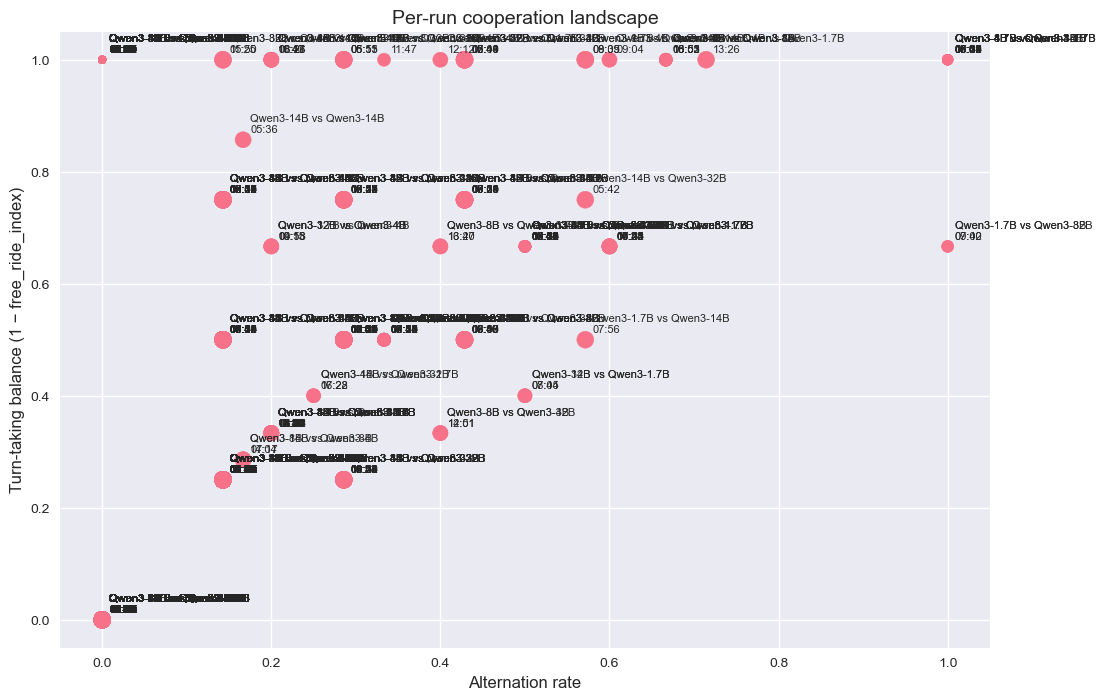

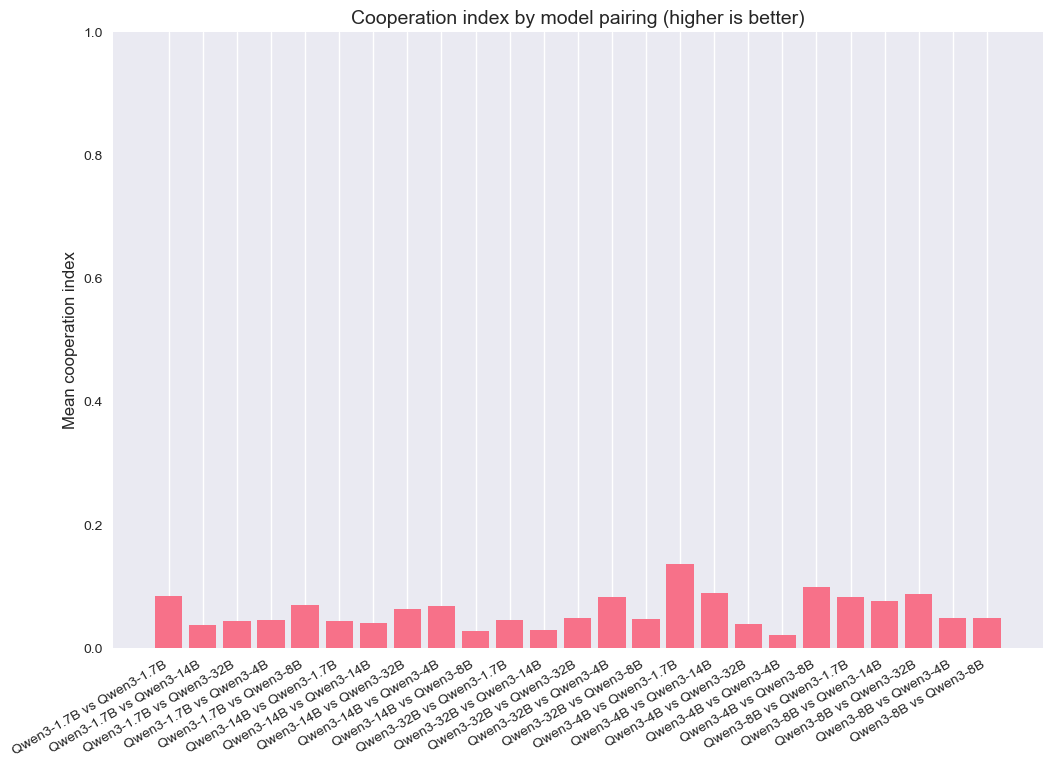

Top pairing by mean cooperation_index:
  Qwen3-4B vs Qwen3-1.7B
  mean_cooperation_index = 0.136
  mean_alternation = 0.174, mean_balance = 0.319
  valid contribution shares: p0 53.4% / p1 46.6%

Coordination modes (per run):
coordination_mode
parallel / conflict-prone     740
batched but fair              210
mutual turn-taking             48
alternating but imbalanced      2


In [80]:
# Self-contained analysis & visualization for cooperation metrics
#
# This cell:
# 1) Loads the provided CSV (embedded as a string).
# 2) Cleans and derives cooperation metrics.
# 3) Produces several informative plots (matplotlib only; one chart per figure).
# 4) Displays a summary table you can sort/filter (falls back to printing if a helper is unavailable).
#
# Key derived measures:
# - balance := 1 - free_ride_index  (closer to 1 => more evenly shared valid steps)
# - cooperation_index := alternation_rate * balance  (simple composite in [0,1])
# - coordination_mode := qualitative quadrant from (alternation_rate, balance)

import io
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Coerce numerics (missing values -> NaN)
num_cols = [
    "p0_valid_actions","p1_valid_actions","p0_total_actions","p1_total_actions",
    "free_ride_index","alternation_rate"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["pair"] = df["p0"] + " vs " + df["p1"]
df["total_valid"] = df["p0_valid_actions"].fillna(0) + df["p1_valid_actions"].fillna(0)

# balance in [0,1], where 1 = perfectly balanced valid turns (free_ride_index=0)
df["balance"] = 1.0 - df["free_ride_index"].clip(lower=0, upper=1)

# Composite cooperation score (simple product, stays in [0,1])
df["cooperation_index"] = (df["alternation_rate"].clip(0,1) * df["balance"]).fillna(0.0)

# Qualitative quadrant
def mode_from(a, b):
    if pd.isna(a) or pd.isna(b):
        return "unknown"
    if a >= 0.5 and b >= 0.5:
        return "mutual turn-taking"
    if a >= 0.5 and b < 0.5:
        return "alternating but imbalanced"
    if a < 0.5 and b >= 0.5:
        return "batched but fair"
    return "parallel / conflict-prone"

df["coordination_mode"] = [mode_from(a, b) for a, b in zip(df["alternation_rate"], df["balance"])]

# -------------
# Aggregations by model pair
# -------------
agg = (
    df.groupby(["p0","p1"], dropna=False)
      .agg(
          runs=("UID", "count"),
          mean_alternation=("alternation_rate", "mean"),
          mean_balance=("balance", "mean"),
          mean_coop_index=("cooperation_index", "mean"),
          total_valid=("total_valid", "sum"),
          p0_valid=("p0_valid_actions","sum"),
          p1_valid=("p1_valid_actions","sum"),
      )
      .reset_index()
)

# Add shares
agg["p0_share_valid"] = agg["p0_valid"] / agg[["p0_valid","p1_valid"]].sum(axis=1).replace(0, np.nan)
agg["p1_share_valid"] = agg["p1_valid"] / agg[["p0_valid","p1_valid"]].sum(axis=1).replace(0, np.nan)

# -------------
# Display tables (interactive in some environments; fallback to print)
# -------------
try:
    from caas_jupyter_tools import display_dataframe_to_user  # available in some hosted envs
    display_dataframe_to_user("Per-run metrics (with derived fields)", df.copy())
    display_dataframe_to_user("Aggregated metrics by model pair", agg.copy())
except Exception:
    print("\nPer-run metrics:")
    # print(df.to_string(index=False))
    # print("\nAggregated metrics by pair:")
    # print(agg.to_string(index=False))

# -------------
# Plots (one figure per chart; no explicit colors or styles)
# -------------
# Scatter: alternation vs balance, size ~ total valid steps
plt.figure()
x = df["alternation_rate"]
y = df["balance"]
sizes = 30 + 15 * df["total_valid"].fillna(0)  # avoid zero-size markers
plt.scatter(x, y, s=sizes)
for xi, yi, uid, pair in zip(x, y, df["UID"], df["pair"]):
    if pd.notna(xi) and pd.notna(yi):
        try:
            hhmm = uid.split("_")[1]          # "HH-MM-SS"
            hhmm = hhmm[:5].replace("-", ":") # "HH:MM"
        except Exception:
            hhmm = uid
        plt.annotate(f"{pair}\n{hhmm}", (xi, yi), textcoords="offset points", xytext=(5,5), fontsize=8)
plt.xlabel("Alternation rate")
plt.ylabel("Turn-taking balance (1 − free_ride_index)")
plt.title("Per-run cooperation landscape")
plt.grid(True)
plt.show()

# Bar: mean cooperation index by pair
plt.figure()
pairs = (agg["p0"] + " vs " + agg["p1"]).astype(str).tolist()
heights = agg["mean_coop_index"].fillna(0).values
positions = np.arange(len(pairs))
plt.bar(positions, heights)
plt.xticks(positions, pairs, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean cooperation index")
plt.title("Cooperation index by model pairing (higher is better)")
plt.grid(axis="y")
plt.show()


# -------------
# Textual summary
# -------------
def fmt_pct(x):
    return "nan" if pd.isna(x) else f"{100*x:.1f}%"

best_row = agg.loc[agg["mean_coop_index"].idxmax()] if not agg.empty else None
if best_row is not None:
    print("Top pairing by mean cooperation_index:")
    print(f"  {best_row['p0']} vs {best_row['p1']}")
    print(f"  mean_cooperation_index = {best_row['mean_coop_index']:.3f}")
    print(f"  mean_alternation = {best_row['mean_alternation']:.3f}, mean_balance = {best_row['mean_balance']:.3f}")
    print(f"  valid contribution shares: p0 {fmt_pct(best_row['p0_share_valid'])} / p1 {fmt_pct(best_row['p1_share_valid'])}")
else:
    print("Aggregation produced no rows.")

print("\nCoordination modes (per run):")
print(df["coordination_mode"].value_counts(dropna=False).to_string())



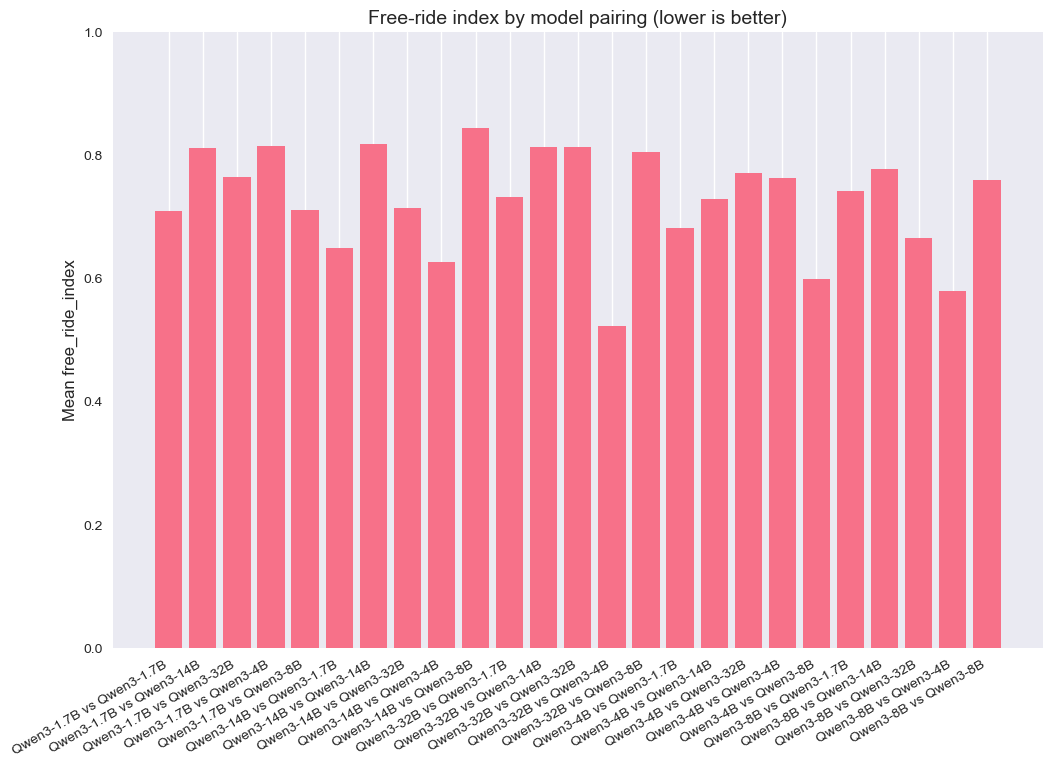

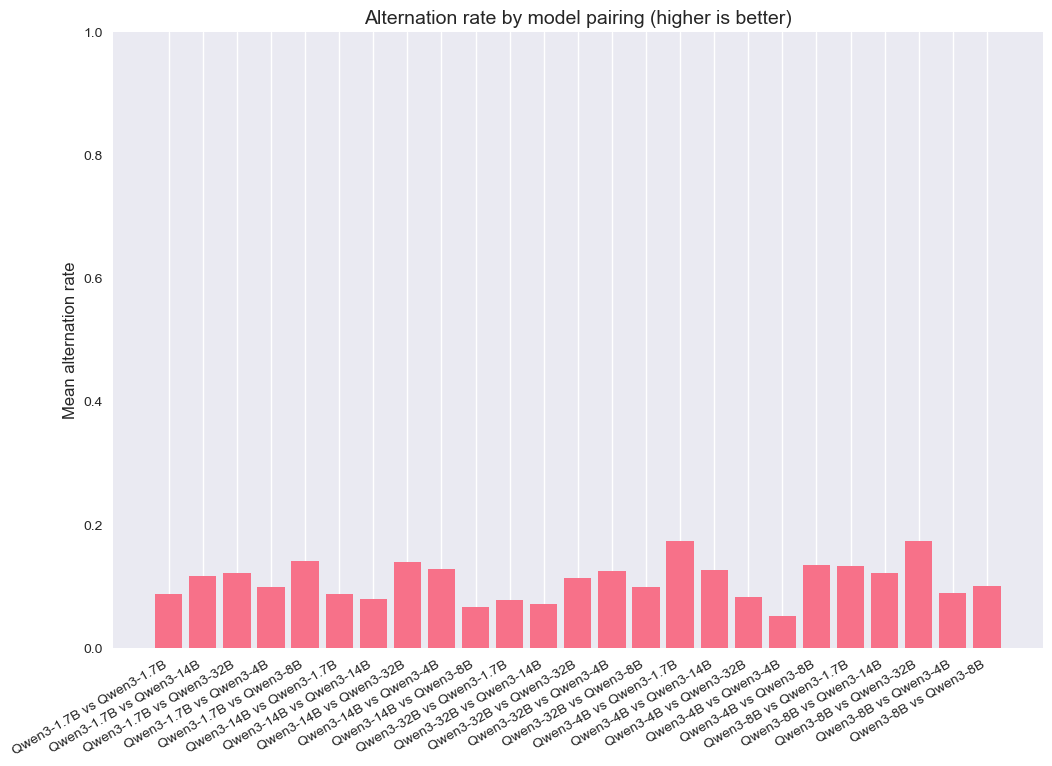

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Build base table in the same pair order as the cooperation plot if `agg` exists.
try:
    base = agg.copy()
    base["pair_label"] = (base["p0"].astype(str) + " vs " + base["p1"].astype(str))
except NameError:
    base = (
        df.groupby(["p0","p1"], dropna=False)
          .agg(mean_alternation=("alternation_rate", "mean"))
          .reset_index()
    )
    base["pair_label"] = (base["p0"].astype(str) + " vs " + base["p1"].astype(str))

# Compute mean free_ride_index per pair and merge (so ordering matches `base`)
fr = (
    df.groupby(["p0","p1"], dropna=False)["free_ride_index"]
      .mean()
      .reset_index(name="mean_free_ride")
)
base = base.merge(fr, on=["p0","p1"], how="left")

pairs = base["pair_label"].tolist()
positions = np.arange(len(pairs))

# ---- Bar: mean free_ride_index by pair ----
plt.figure()
heights = base["mean_free_ride"].clip(0, 1).fillna(0).to_numpy()
plt.bar(positions, heights)
plt.xticks(positions, pairs, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean free_ride_index")
plt.title("Free-ride index by model pairing (lower is better)")
plt.grid(axis="y")
plt.show()

# ---- Bar: mean alternation_rate by pair ----
plt.figure()
heights = base["mean_alternation"].clip(0, 1).fillna(0).to_numpy()
plt.bar(positions, heights)
plt.xticks(positions, pairs, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean alternation rate")
plt.title("Alternation rate by model pairing (higher is better)")
plt.grid(axis="y")
plt.show()


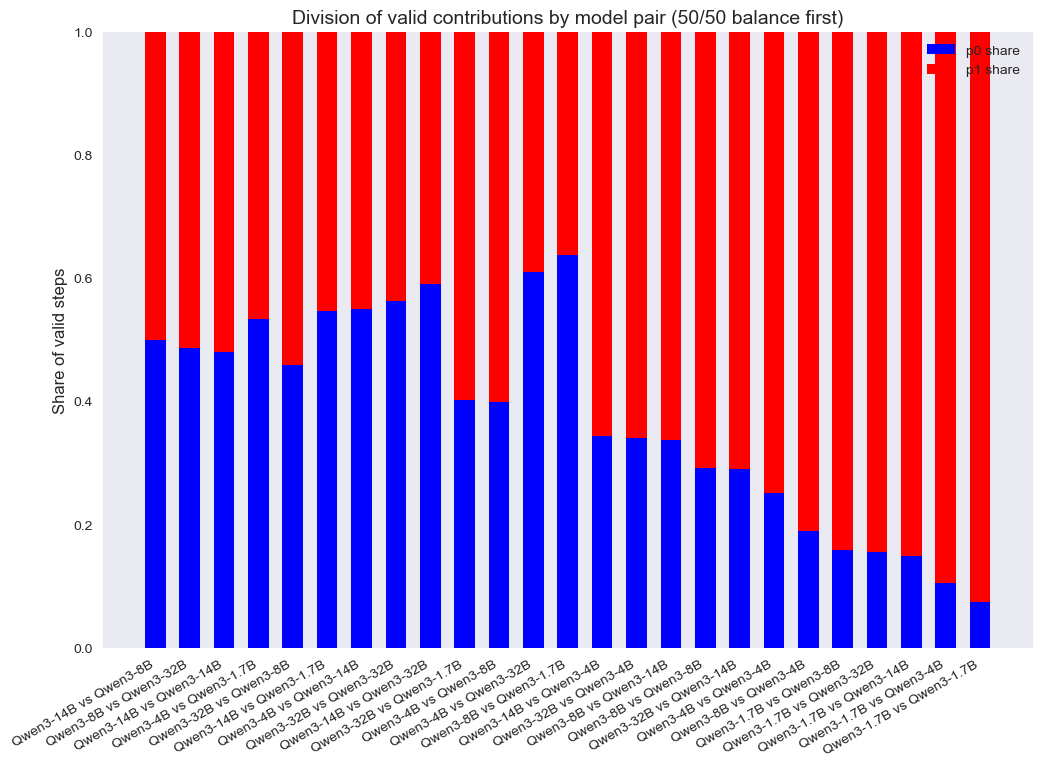

In [82]:
# Stacked bars: balance-first ordering (closest to 50/50 first)
plt.figure()
width = 0.6

pairs = (agg["p0"] + " vs " + agg["p1"]).astype(str).tolist()
p0_share = agg["p0_share_valid"].astype(float).to_numpy()
p1_share = agg["p1_share_valid"].astype(float).to_numpy()
total_valid = agg["total_valid"].fillna(0).to_numpy()

# Closeness to perfect balance (0.5)
closeness = np.abs(p0_share - 0.5)

# Push invalid/empty cases to the end
invalid = ~np.isfinite(closeness) | (total_valid == 0)
closeness[invalid] = np.inf

# Order: first by smallest closeness (50/50 first), then by larger total_valid
order = np.lexsort((-total_valid, closeness))

# Apply ordering
pairs_sorted = [pairs[i] for i in order]
p0_sorted = p0_share[order]
p1_sorted = p1_share[order]
xpos = np.arange(len(pairs_sorted))

# Plot
plt.bar(xpos, p0_sorted, width=width, label="p0 share", color="blue")
plt.bar(xpos, p1_sorted, bottom=p0_sorted, width=width, label="p1 share", color="red")
plt.xticks(xpos, pairs_sorted, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Share of valid steps")
plt.title("Division of valid contributions by model pair (50/50 balance first)")
plt.legend()
plt.grid(axis="y")
plt.show()


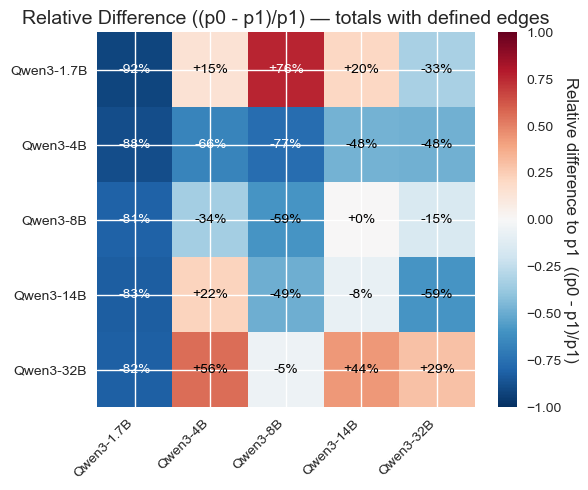

In [102]:
# Relative difference heatmap for (p0 vs p1) using r = (a - b) / b
# Semantics:
#   b > 0      -> r = (a - b)/b
#   b = 0, a>0 -> r = +1  ( +100% ; "a did it all")
#   a = 0, b>0 -> r = -1  ( -100% ; "b did it all")
#   a = 0, b=0 -> r = 0   ( 0% ; equal)
#
# Aggregation: sum counts across runs, then compute ONE ratio per (p0,p1).
# Requires: pandas, numpy, matplotlib, re (stdlib)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import re

# --- 1) Validate input --------------------------------------------------------
required = {"p0","p1","p0_valid_actions","p1_valid_actions"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

# --- 2) Sum counts per (p0,p1) -----------------------------------------------
agg = (
    df.groupby(["p0","p1"], as_index=False)
      .agg(a_sum=("p0_valid_actions","sum"),
           b_sum=("p1_valid_actions","sum"),
           runs=("p0","size"))
)

a = agg["a_sum"].to_numpy(dtype=float)
b = agg["b_sum"].to_numpy(dtype=float)

# --- 3) Piecewise ratio with your edge rules ---------------------------------
# Default: r = (a - b)/b when b > 0
r = np.empty_like(a, dtype=float)
pos_b = b > 0
r[pos_b] = (a[pos_b] - b[pos_b]) / b[pos_b]

# b = 0, a > 0 -> +1
mask_b0_a_pos = (b == 0) & (a > 0)
r[mask_b0_a_pos] = 1.0

# a = 0, b > 0 -> -1  (already handled by formula when b>0)
# a = 0, b = 0 -> 0
mask_b0_a0 = (b == 0) & (a == 0)
r[mask_b0_a0] = 0.0

agg["rel"] = r  # in [-1, +∞), with special cases mapped to {-1, 0, +1} as above

# --- 4) Pivot to matrix and numeric-aware ordering ---------------------------
def _natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.findall(r"\d+|\D+", str(s))]

models = sorted(set(df["p0"]).union(set(df["p1"])), key=_natural_key)

heat = (
    agg.pivot(index="p1", columns="p0", values="rel")
       .reindex(index=models, columns=models)
)

# --- 5) Plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

vals = heat.values
finite = np.isfinite(vals)

# Lower bound is -1 by construction; choose a robust positive cap for color scale.
pos_vals = vals[(finite) & (vals > 0)]
if pos_vals.size:
    vmax = max(1.0, float(np.quantile(pos_vals, 0.98)))  # at least symmetric vs -1
else:
    vmax = 1.0
vmin = -1.0

norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
im = ax.imshow(np.clip(np.where(finite, vals, np.nan), vmin, vmax),
               aspect="auto", cmap="RdBu_r", interpolation="nearest",
               resample=False, norm=norm)

ax.set_title("Relative Difference ((p0 - p1)/p1) — totals with defined edges")
ax.set_xticks(np.arange(heat.shape[1])); ax.set_yticks(np.arange(heat.shape[0]))
ax.set_xticklabels(heat.columns.tolist(), rotation=45, ha="right")
ax.set_yticklabels(heat.index.tolist())
ax.tick_params(axis="both", length=0)

# Annotate as percentages (+50%, −100%, etc.)
cmap_obj = im.cmap
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isfinite(v):
            continue
        rgba = cmap_obj(norm(np.clip(v, vmin, vmax)))
        lum = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
        color = "white" if lum < 0.5 else "black"
        ax.text(j, i, f"{v:+.0%}", ha="center", va="center", color=color)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Relative difference to p1  ((p0 - p1)/p1)", rotation=270, labelpad=12)

fig.tight_layout()

# --- 6) Save artifacts --------------------------------------------------------
out_dir = Path("./")
(agg[["p0","p1","a_sum","b_sum","rel","runs"]]
 .rename(columns={"p1":"agent_p1","p0":"agent_p0","rel":"relative_diff_to_p1"})
 .to_csv(out_dir / "agent_pairing_relative_to_p1.csv", index=False))

fig.savefig(out_dir / "heatmap_count_rel_to_p1.png", dpi=200, bbox_inches="tight")
plt.show()


in relation to p1, p0 did: ^^^